# Notebook: Salariul operatorilor
### Author: Vasile Bujor
### Description: Calcul indicatori salariali (brut, net, mediu)

In [ ]:
#Variabile Globale
luni = {
    "01": "Ianuarie", "02": "Februarie", "03": "Martie", "04": "Aprilie", "05": "Mai", "06": "Iunie",
    "07": "Iulie", "08": "August", "09": "Septembrie", "10": "Octombrie", "11": "Noiembrie", "12": "Decembrie"}
filenamePr = "AFM_05_2026_pr.csv"
filenameRecalc = "AFM_04_2026.csv"
filenamePrPrev = "AFM_04_2026_pr.csv"
CBGCfilenamePr = "CBGC_05_2026_pr.csv"
CBGCfilenameRecalc = "CBGC_04_2026.csv"
CBGCfilenamePrPrev = "CBGC_04_2026_pr.csv"
complexitate = 3.8
cost_chest_conventional = 197.1
cost_nr = 59.1
cost_conventional_EBS = 39.4
cost_prima_pers_PRO = 160
cost_alte_pers_PRO = 117
cost_pers_NONPRO = 25
extra_spor = 0

In [ ]:
import pandas as pd
#import numpy as np
#import os
pd.set_option('display.max_columns', None)

In [ ]:
#Date preliminare pentru luna curenta
luna = filenamePr.split("_")[1]
luna_txt = luni.get(luna, "Necunoscut")
dataAFM = pd.read_csv("DataInput/" + filenamePr, encoding="utf-8")
dataCBGC = pd.read_csv("DataInput/" + CBGCfilenamePr)
print(f"Salariul pentru Luna: {luna_txt}")
print("Suma gospoadriilor cu accepturi PA1 =", dataAFM["PA1"].sum(), "(AFM preliminar)")
print("Suma gospoadriilor cu accepturi PA1 =", dataCBGC["PA1"].sum(), "(CBCG preliminar)")
dataAFM.drop(columns=["ENUM_NAME"], errors="ignore")
#dataAFM.head()

Salariul pentru Luna: Mai
Suma gospoadriilor cu accepturi PA1 = 617 (AFM preliminar)
Suma gospoadriilor cu accepturi PA1 = 794.0 (CBCG preliminar)


,Anul,Luna,CRS,SUP,ENUM,INT_START,INT_END,SITLOC1,SITLOC2,SITLOC3,SITLOC4,SITLOC6,SITLOC5,SITLOC7,SITLOC8,CNT_SITLOC,CNT_SITLOC_NON,PA1,PA2,PA3,PA4,PA5,PA61,PA62,PA63,PA64,PA65,PA66,PA67,PA68,PA69,PA7,PA8,PA9,PA10,PA11,PERS_PRO,PERS_NONPRO,NR,EBS,Total PA
0,2026,5,Nord,1102,101,18.05.2026 13:58,24.05.2026 20:01,8,1,0,0,0,0,0,0,9,1,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,2,0,1,8
1,2026,5,Nord,1101,102,13.05.2026 16:33,24.05.2026 18:35,2,1,0,0,0,0,0,0,3,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,3,1,0,2,3
2,2026,5,Nord,1101,103,22.05.2026 13:19,25.05.2026 16:50,3,0,0,0,0,0,0,0,3,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,4,1,0,1,3
3,2026,5,Nord,1107,104,12.05.2026 13:56,22.05.2026 19:53,4,0,0,0,0,0,0,0,4,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,6,5,0,1,4
4,2026,5,Nord,1108,105,15.05.2026 15:08,15.05.2026 15:13,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,2026,5,Chisinau,1406,440,16.05.2026 10:04,22.05.2026 13:46,10,0,0,0,0,0,0,0,10,0,5,0,0,0,0,0,1,0,0,2,0,0,0,0,1,1,0,0,0,9,2,3,2,10
144,2026,5,Chisinau,1403,441,14.05.2026 11:47,24.05.2026 12:38,6,0,0,0,0,0,0,0,6,0,3,1,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,5,1,3,0,6
145,2026,5,Chisinau,1403,442,11.05.2026 19:38,26.05.2026 11:26,13,0,0,0,0,0,0,0,13,0,8,1,0,0,0,0,0,0,0,3,0,1,0,0,0,0,0,0,0,11,2,5,0,13
146,2026,5,Chisinau,1403,443,23.05.2026 18:19,23.05.2026 18:48,3,0,0,0,0,0,0,0,3,0,1,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,1,2,0,3


In [ ]:
#Date Recalculate
lunaRecalc = filenameRecalc.split("_")[1]
lunaRecalc_txt = luni.get(lunaRecalc, "Necunoscut")
dataAFMRecalc = pd.read_csv("DataInput/" + filenameRecalc, encoding="utf-8-sig")
dataCBGCRecalc = pd.read_csv("DataInput/" + CBGCfilenameRecalc)
print(f"Salariul Recalculat pentru Luna: {lunaRecalc_txt}")
print("Suma gospoadriilor AFM cu accepturi luna precedenta PA1 =", dataAFMRecalc["PA1"].sum())
print("Suma gospoadriilor CBGC cu accepturi luna precedenta PA1 =", dataCBGCRecalc["PA1"].sum())

Salariul Recalculat pentru Luna: Aprilie
Suma gospoadriilor AFM cu accepturi luna precedenta PA1 = 1857
Suma gospoadriilor CBGC cu accepturi luna precedenta PA1 = 789


In [ ]:
#Date preliminar din luna precedenta
lunaPrPrev = filenamePrPrev.split("_")[1]
lunaPrPrev_txt = luni.get(lunaPrPrev, "Necunoscut")
dataAFMPrPrev = pd.read_csv("DataInput/" + filenamePrPrev, encoding="utf-8-sig")
dataCBGCPrPrev = pd.read_csv("DataInput/" + CBGCfilenamePrPrev)
print(f"Salariul pentru Luna: {lunaPrPrev_txt}")
print("Suma gospoadriilor AFM cu accepturi PA1 =", dataAFMPrPrev["PA1"].sum())
print("Suma gospoadriilor CBGC cu accepturi PA1 =", dataCBGCPrPrev["PA1"].sum())

Salariul pentru Luna: Aprilie
Suma gospoadriilor AFM cu accepturi PA1 = 1033
Suma gospoadriilor CBGC cu accepturi PA1 = 805


In [ ]:
#Date preliminare AFM
dataAFM["Total"] = dataAFM.loc[:, "PA1":"PA11"].sum(axis=1)
dataAFM["NR"] = dataAFM.loc[:,["PA2","PA61","PA62","PA63","PA64","PA65","PA66","PA67","PA68","PA69","PA11"]].sum(axis=1)
dataAFM["EBS"] = dataAFM.loc[:,["PA3","PA4","PA5","PA7","PA8","PA9","PA10","CNT_SITLOC_NON"]].sum(axis=1)
dataAFM["EBS_PROC"] = round(dataAFM["EBS"]/dataAFM["Total"]*100, 1)
#dataAFM["RataRaspuns"] = dataAFM["PA1"]/dataAFM["NR"]
dataAFMGroup = dataAFM.groupby(["ENUM"]).sum()
print("AFM Nr. Operatori=",len(dataAFMGroup))
dataAFMGroup.drop(columns=["ENUM_NAME"], errors="ignore")

AFM Nr. Operatori= 145


,Anul,Luna,CRS,SUP,INT_START,INT_END,SITLOC1,SITLOC2,SITLOC3,SITLOC4,SITLOC6,SITLOC5,SITLOC7,SITLOC8,CNT_SITLOC,CNT_SITLOC_NON,PA1,PA2,PA3,PA4,PA5,PA61,PA62,PA63,PA64,PA65,PA66,PA67,PA68,PA69,PA7,PA8,PA9,PA10,PA11,PERS_PRO,PERS_NONPRO,NR,EBS,Total PA,Total,EBS_PROC
ENUM,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
101,2026,5,Nord,1102,18.05.2026 13:58,24.05.2026 20:01,8,1,0,0,0,0,0,0,9,1,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,2,0,1,8,8,12.5
102,2026,5,Nord,1101,13.05.2026 16:33,24.05.2026 18:35,2,1,0,0,0,0,0,0,3,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,3,1,0,3,3,3,100.0
103,2026,5,Nord,1101,22.05.2026 13:19,25.05.2026 16:50,3,0,0,0,0,0,0,0,3,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,4,1,0,1,3,3,33.3
104,2026,5,Nord,1107,12.05.2026 13:56,22.05.2026 19:53,4,0,0,0,0,0,0,0,4,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,6,5,0,1,4,4,25.0
105,2026,5,Nord,1108,15.05.2026 15:08,15.05.2026 15:13,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,2026,5,Chisinau,1406,16.05.2026 10:04,22.05.2026 13:46,10,0,0,0,0,0,0,0,10,0,5,0,0,0,0,0,1,0,0,2,0,0,0,0,1,1,0,0,0,9,2,3,2,10,10,20.0
441,2026,5,Chisinau,1403,14.05.2026 11:47,24.05.2026 12:38,6,0,0,0,0,0,0,0,6,0,3,1,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,5,1,3,0,6,6,0.0
442,2026,5,Chisinau,1403,11.05.2026 19:38,26.05.2026 11:26,13,0,0,0,0,0,0,0,13,0,8,1,0,0,0,0,0,0,0,3,0,1,0,0,0,0,0,0,0,11,2,5,0,13,13,0.0


In [ ]:
#Date preliminare CBGC
dataCBGC["Total"] = dataCBGC.loc[:, "PA1":"PA11"].sum(axis=1)
dataCBGC["NR"] = dataCBGC.loc[:,["PA2","PA61","PA62","PA63","PA64","PA65","PA66","PA67","PA68","PA69","PA11"]].sum(axis=1)
dataCBGC["EBS"] = dataCBGC.loc[:,["PA3","PA4","PA5","PA7","PA8","PA9","PA10","SIL2","SIL3","SIL4","SIL5","SIL6","SIL7","SIL8"]].sum(axis=1)
dataCBGC["EBS_PROC"] = round(dataCBGC["EBS"]/dataCBGC["Total"]*100, 1)
#dataAFM["RataRaspuns"] = dataAFM["PA1"]/dataAFM["NR"]
dataCBGCGroup = dataCBGC.groupby(["ENUM"]).sum()
print("CBGC Nr. Operatori=",len(dataCBGCGroup))
dataCBGCGroup.drop(columns=["Nume operator"], errors="ignore")

CBGC Nr. Operatori= 145


,CENTR,SIL1,SIL2,SIL3,SIL4,SIL5,SIL6,SIL7,SIL8,PA1,PA2,PA3,PA4,PA5,PA61,PA62,PA63,PA64,PA65,PA66,PA67,PA68,PA69,PA7,PA8,PA9,PA10,PA11,PA_TOTAL,NR,EBS,Total,EBS_PROC
ENUM,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
101,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,0.0,0.0,8.0,0.0
102,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,0.0,0.0,7.0,0.0
103,281.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,0.0,0.0,7.0,0.0
104,294.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,0.0,4.0,0.0
105,307.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,0.0,0.0,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,0.0,0.0,5.0,0.0
441,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,1.0,0.0
442,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,0.0,0.0,6.0,0.0


In [ ]:
#Date recalculate AFM
dataAFMRecalc["Total"] = dataAFMRecalc.loc[:, "PA1":"PA11"].sum(axis=1)
dataAFMRecalc["NR"] = dataAFMRecalc.loc[:,["PA2","PA61","PA62","PA63","PA64","PA65","PA66","PA67","PA68","PA69","PA11"]].sum(axis=1)
dataAFMRecalc["EBS"] = dataAFMRecalc.loc[:,["PA3","PA5","PA7","PA8","PA9","PA10","CNT_SITLOC_NON"]].sum(axis=1)
dataAFMRecalc["EBS_PROC"] = round(dataAFMRecalc["EBS"]/dataAFMRecalc["Total"]*100, 1)
dataAFMRecalc["prima_pers_PRO"] = dataAFMRecalc["PA1"]
dataAFMRecalc["alte_pers_PRO"] = dataAFMRecalc["PERS_PRO"] - dataAFMRecalc["prima_pers_PRO"]
dataAFMRecalc["sal_AFM_pers_recalc"] = (dataAFMRecalc["prima_pers_PRO"] * cost_prima_pers_PRO) +\
    (dataAFMRecalc["alte_pers_PRO"] * cost_alte_pers_PRO) +\
    (dataAFMRecalc["PERS_NONPRO"] * cost_pers_NONPRO)
#dataAFM["RataRaspuns"] = dataAFM["PA1"]/dataAFM["NR"]
dataReacalcAFMGroup = dataAFMRecalc.groupby(["ENUM"]).sum()
print("Nr. Operatori=",len(dataReacalcAFMGroup))
print(f"Nr totala de NR pentru {lunaRecalc_txt} = ",dataReacalcAFMGroup.loc[:,["NR"]].sum())
print(f"Nr totala de EBS pentru {lunaRecalc_txt} = ",dataReacalcAFMGroup.loc[:,["EBS"]].sum())
print(f"Nr totala de prima_pers_PRO pentru {lunaRecalc_txt} = ",dataReacalcAFMGroup.loc[:,["prima_pers_PRO"]].sum())
print(f"Nr totala de alte_pers_PRO pentru {lunaRecalc_txt} = ",dataReacalcAFMGroup.loc[:,["alte_pers_PRO"]].sum())
print(f"Nr totala de sal_AFM_pers_recalc pentru {lunaRecalc_txt} = ",dataReacalcAFMGroup.loc[:,["sal_AFM_pers_recalc"]].sum())
#dataReacalcAFMGroup.loc[418]
dataReacalcAFMGroup.drop(columns=["ENUM_NAME"], errors="ignore")

Nr. Operatori= 145
Nr totala de NR pentru Aprilie =  NR    540
dtype: int64
Nr totala de EBS pentru Aprilie =  EBS    490
dtype: int64
Nr totala de prima_pers_PRO pentru Aprilie =  prima_pers_PRO    1857
dtype: int64
Nr totala de alte_pers_PRO pentru Aprilie =  alte_pers_PRO    1358
dtype: int64
Nr totala de sal_AFM_pers_recalc pentru Aprilie =  sal_AFM_pers_recalc    476606
dtype: int64


,Anul,Luna,CRS,SUP,INT_START,INT_END,SITLOC1,SITLOC2,SITLOC3,SITLOC4,SITLOC6,SITLOC5,SITLOC7,SITLOC8,CNT_SITLOC,CNT_SITLOC_NON,PA1,PA2,PA3,PA4,PA5,PA61,PA62,PA63,PA64,PA65,PA66,PA67,PA68,PA69,PA7,PA8,PA9,PA10,PA11,PERS_PRO,PERS_NONPRO,NR,EBS,Total PA,Total,EBS_PROC,prima_pers_PRO,alte_pers_PRO,sal_AFM_pers_recalc
ENUM,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
101,4052,8,NordNord,2204,14.04.2026 14:4209.05.2026 18:35,12.05.2026 16:2012.05.2026 15:09,14,0,0,0,0,0,0,0,14,0,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25,14,0,0,14,14,0.0,14,11,3877
102,2026,4,Nord,1101,15.04.2026 16:09,17.05.2026 19:23,18,2,0,0,0,0,0,0,20,2,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,27,11,0,2,18,18,11.1,18,9,4208
103,2026,4,Nord,1101,07.04.2026 14:06,15.05.2026 14:22,21,0,0,0,0,0,0,0,21,0,19,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,31,4,0,2,21,21,9.5,19,12,4544
104,2026,4,Nord,1107,07.04.2026 15:00,17.05.2026 17:22,17,0,0,0,0,1,0,0,18,1,13,0,0,0,1,0,2,1,0,0,0,0,0,0,0,0,0,0,0,21,2,3,2,17,17,11.8,13,8,3066
105,2026,4,Nord,1108,16.04.2026 12:35,18.05.2026 08:31,20,0,0,0,0,0,0,0,20,0,15,0,0,0,0,0,1,1,0,0,0,0,0,0,0,3,0,0,0,20,2,2,3,20,20,15.0,15,5,3035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,2026,4,Chisinau,1406,16.04.2026 16:07,20.05.2026 14:54,23,0,0,0,0,0,0,0,23,0,11,0,0,0,1,0,3,1,0,1,1,0,0,0,3,2,0,0,0,21,8,6,6,23,23,26.1,11,10,3130
441,2026,4,Chisinau,1403,15.04.2026 19:11,16.05.2026 13:39,30,0,0,0,0,0,0,0,30,0,9,0,0,0,1,3,1,0,1,10,1,0,0,0,1,2,1,0,0,18,5,16,5,30,30,16.7,9,9,2618
442,2026,4,Chisinau,1403,14.04.2026 15:50,14.05.2026 16:39,17,0,0,0,0,0,0,0,17,0,5,2,0,0,1,0,0,0,0,5,0,2,0,0,2,0,0,0,0,6,0,9,3,17,17,17.6,5,1,917


In [ ]:
#Date recalculate CBGC
dataCBGCRecalc["Total"] = dataCBGCRecalc.loc[:, "PA1":"PA11"].sum(axis=1)
dataCBGCRecalc["NR"] = dataCBGCRecalc.loc[:,["PA2","PA61","PA62","PA63","PA64","PA65","PA66","PA67","PA68","PA69","PA11"]].sum(axis=1)
dataCBGCRecalc["EBS"] = dataCBGCRecalc.loc[:,["PA3","PA4","PA5","PA7","PA8","PA9","PA10","SIL2","SIL3","SIL4","SIL5","SIL6","SIL7","SIL8"]].sum(axis=1)
dataCBGCRecalc["EBS_PROC"] = round(dataCBGCRecalc["EBS"]/dataCBGCRecalc["Total"]*100, 1)
#dataAFM["RataRaspuns"] = dataAFM["PA1"]/dataAFM["NR"]
dataReacalcCBGCGroup = dataCBGCRecalc.groupby(["ENUM"]).sum()
print("Nr. Operatori=",len(dataReacalcCBGCGroup))
dataReacalcCBGCGroup.drop(columns=["Nume operator"], errors="ignore")

Nr. Operatori= 145


,CENTR,SIL1,SIL2,SIL3,SIL4,SIL5,SIL6,SIL7,SIL8,PA1,PA2,PA3,PA4,PA5,PA61,PA62,PA63,PA64,PA65,PA66,PA67,PA68,PA69,PA7,PA8,PA9,PA10,PA11,PA_TOTAL,NR,EBS,Total,EBS_PROC
ENUM,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
101,1.0,9,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,1,0,0,0,3,0,0,0,9,1,3,9,33.3
102,27.0,9,0,0,0,0,0,0,0,8,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,0,1,9,11.1
103,281.0,9,0,0,0,0,0,0,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,0,0,9,0.0
104,294.0,9,0,0,0,0,0,0,0,7,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,9,2,0,9,0.0
105,307.0,9,0,0,0,0,0,0,0,7,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,9,0,2,9,22.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,0.0,15,0,0,0,0,0,0,0,6,0,0,0,3,0,1,0,0,0,1,0,1,0,0,2,1,0,0,15,3,6,15,40.0
441,0.0,15,0,0,0,0,0,0,0,3,3,0,0,1,1,0,0,1,2,0,0,0,0,0,3,1,0,0,15,7,5,15,33.3
442,0.0,15,0,0,0,0,0,0,0,4,5,0,0,0,0,0,0,3,1,0,0,0,0,1,1,0,0,0,15,9,2,15,13.3


In [ ]:
#Date preliminare din luna precedenta AFM
dataAFMPrPrev["Total"] = dataAFMPrPrev.loc[:, "PA1":"PA11"].sum(axis=1)
dataAFMPrPrev["NR"] = dataAFMPrPrev.loc[:,["PA2","PA61","PA62","PA63","PA64","PA65","PA66","PA67","PA68","PA69","PA11"]].sum(axis=1)
if lunaPrPrev_txt == "Februarie":
    dataAFMPrPrev["EBS"] = dataAFMPrPrev.loc[:,["PA3","PA4","PA5","PA7","PA8","PA9","PA10","SITLOC2","SITLOC3","SITLOC4","SITLOC5","SITLOC6","SITLOC7","SITLOC8"]].sum(axis=1)
else:
    dataAFMPrPrev["EBS"] = dataAFMPrPrev.loc[:,["PA3","PA4","PA5","PA7","PA8","PA9","PA10","CNT_SITLOC_NON"]].sum(axis=1)
#dataAFMPrPrev["EBS"] = dataAFMPrPrev.loc[:,["PA3","PA4","PA5","PA7","PA8","PA9","PA10","CNT_SITLOC_NON"]].sum(axis=1)
dataAFMPrPrev["EBS_PROC"] = round(dataAFMPrPrev["EBS"]/dataAFMPrPrev["Total"]*100, 1)
#dataAFM["RataRaspuns"] = dataAFM["PA1"]/dataAFM["NR"]
dataAFMPrpRrevGroup = dataAFMPrPrev.groupby(["ENUM"]).sum()
print("Nr. Operatori=",len(dataAFMPrpRrevGroup))
#dataAFMPrpRrevGroup[dataAFMPrpRrevGroup["SITLOC2"] > 0]
dataAFMPrpRrevGroup.drop(columns=["ENUM_NAME"], errors="ignore")

Nr. Operatori= 145


,ANUL,LUNA,CRS,SUP,INT_START,INT_END,SITLOC1,SITLOC2,SITLOC3,SITLOC4,SITLOC6,SITLOC5,SITLOC7,SITLOC8,CNT_SITLOC,CNT_SITLOC_NON,PA2,PA3,PA1,PA4,PA5,PA61,PA63,PA64,PA62,PA65,PA66,PA67,PA69,PA68,PA7,PA8,PA9,PA10,PERS_PRO,PERS_NONPRO,NR,EBS,PA11,Total,EBS_PROC
ENUM,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
101,2026,4,Nord,1102,14.04.2026 14:42,28.04.2026 11:10,12,0,0,0,0,0,0,0,12,0,0,0,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,12,0,0,0,44,0.0
102,2026,4,Nord,1101,15.04.2026 16:09,27.04.2026 09:12,11,0,0,0,0,0,0,0,11,0,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,18,10,0,0,0,39,0.0
103,2026,4,Nord,1101,07.04.2026 14:06,27.04.2026 11:19,11,0,0,0,0,0,0,0,11,0,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19,1,0,0,0,31,0.0
104,2026,4,Nord,1107,07.04.2026 15:00,23.04.2026 10:12,12,0,0,0,0,0,0,0,12,0,0,0,8,0,1,0,1,0,2,0,0,0,0,0,0,0,0,0,12,1,3,1,0,29,3.4
105,2026,4,Nord,1108,16.04.2026 12:35,27.04.2026 09:01,12,0,0,0,0,0,0,0,12,0,0,0,7,0,0,0,1,0,1,0,0,0,0,0,0,3,0,0,9,0,2,3,0,26,11.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,2026,4,Chisinau,1406,16.04.2026 16:07,27.04.2026 09:36,11,0,0,0,0,0,0,0,11,0,0,0,7,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,15,8,2,2,0,38,5.3
441,2026,4,Chisinau,1403,15.04.2026 19:11,21.04.2026 19:48,12,0,0,0,0,0,0,0,12,0,0,0,5,0,0,1,0,0,0,4,1,0,0,0,1,0,0,0,12,4,6,1,0,35,2.9
442,2026,4,Chisinau,1403,14.04.2026 15:50,21.04.2026 16:53,11,0,0,0,0,0,0,0,11,0,2,0,3,0,0,0,0,0,0,3,0,2,0,0,1,0,0,0,3,0,7,1,0,20,5.0


In [ ]:
#Date preliminare din luna precedenta CBGC
dataCBGCPrPrev["Total"] = dataCBGCPrPrev.loc[:, "PA1":"PA11"].sum(axis=1)
dataCBGCPrPrev["NR"] = dataCBGCPrPrev.loc[:,["PA2","PA61","PA62","PA63","PA64","PA65","PA66","PA67","PA68","PA69","PA11"]].sum(axis=1)
dataCBGCPrPrev["EBS"] = dataCBGCPrPrev.loc[:,["PA3","PA4","PA5","PA7","PA8","PA9","PA10","SIL2","SIL3","SIL4","SIL5","SIL6","SIL7","SIL8"]].sum(axis=1)
dataCBGCPrPrev["EBS_PROC"] = round(dataCBGCPrPrev["EBS"]/dataCBGCPrPrev["Total"]*100, 1)
#dataAFM["RataRaspuns"] = dataAFM["PA1"]/dataAFM["NR"]
dataCBGCPrpRrevGroup = dataCBGCPrPrev.groupby(["ENUM"]).sum()
print("CBGC Nr. Operatori=",len(dataCBGCPrpRrevGroup))
#dataAFMPrpRrevGroup[dataAFMPrpRrevGroup["SITLOC2"] > 0]
dataCBGCPrpRrevGroup

CBGC Nr. Operatori= 145


,CENTR,SIL1,SIL2,SIL3,SIL4,SIL5,SIL6,SIL7,SIL8,PA1,PA2,PA3,PA4,PA5,PA61,PA62,PA63,PA64,PA65,PA66,PA67,PA68,PA69,PA7,PA8,PA9,PA10,PA11,Total,NR,EBS,EBS_PROC
ENUM,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
101,1,9,0,0,0,0,0,0,0,6,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,9.0,0,3.0,33.3
102,27,9,0,0,0,0,0,0,0,8,0,0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9.0,0,1.0,11.1
103,281,9,0,0,0,0,0,0,0,9,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9.0,0,0.0,0.0
104,294,9,0,0,0,0,0,0,0,7,0,0,0.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,9.0,2,0.0,0.0
105,307,9,0,0,0,0,0,0,0,7,0,0,0.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,9.0,0,2.0,22.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,656,15,0,0,0,0,0,0,0,6,0,0,0.0,3,0,1,0,0,0,1,0,1,0,0,2,1,0,0,15.0,3,6.0,40.0
441,636,15,0,0,0,0,0,0,0,3,3,0,0.0,1,1,0,0,1,2,0,0,0,0,0,3,1,0,0,15.0,7,5.0,33.3
442,640,15,0,0,0,0,0,0,0,4,5,0,0.0,0,0,0,0,3,1,0,0,0,0,1,1,0,0,0,15.0,9,2.0,13.3


In [ ]:
#Date preliminare luna curenta AFM+CBGC
dataFinal = dataAFMGroup[["Total","PA1","NR",'EBS',"ENUM_NAME"]].merge(
    dataCBGCGroup[["Total","PA1","NR",'EBS']],
    on="ENUM",
    suffixes=('_AFM','_CBGC')
)
dataFinal["cbgc_conventional"] = dataFinal["PA1_CBGC"] * complexitate
dataFinal["sal_chest_completate"] = (dataFinal["cbgc_conventional"] + dataFinal["PA1_AFM"]) * cost_chest_conventional
dataFinal["sal_NR"] = 0
dataFinal["sal_EBS"] = 0
dataFinal[f"sal_{luna_txt}_preliminar"] = dataFinal[["sal_chest_completate","sal_NR","sal_EBS"]].sum(axis=1)
print(f"Nr totala de chestionare acceptate pentru {luna_txt} = ",dataFinal.loc[:,["PA1_AFM","PA1_CBGC"]].sum())
print(f"Suma totala preliminara pentru {luna_txt} = ",dataFinal[f"sal_{luna_txt}_preliminar"].sum())
dataFinal.drop(columns=["ENUM_NAME"], errors="ignore")

Nr totala de chestionare acceptate pentru Mai =  PA1_AFM     617.0
PA1_CBGC    794.0
dtype: float64
Suma totala preliminara pentru Mai =  716300.82


,Total_AFM,PA1_AFM,NR_AFM,EBS_AFM,Total_CBGC,PA1_CBGC,NR_CBGC,EBS_CBGC,cbgc_conventional,sal_chest_completate,sal_NR,sal_EBS,sal_Mai_preliminar
ENUM,,,,,,,,,,,,,
101,8,8,0,1,8.0,8.0,0.0,0.0,30.4,7568.64,0,0,7568.64
102,3,1,0,3,7.0,7.0,0.0,0.0,26.6,5439.96,0,0,5439.96
103,3,2,0,1,7.0,7.0,0.0,0.0,26.6,5637.06,0,0,5637.06
104,4,3,0,1,4.0,4.0,0.0,0.0,15.2,3587.22,0,0,3587.22
105,1,1,0,0,7.0,7.0,0.0,0.0,26.6,5439.96,0,0,5439.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,10,5,3,2,5.0,5.0,0.0,0.0,19.0,4730.40,0,0,4730.40
441,6,3,3,0,1.0,1.0,0.0,0.0,3.8,1340.28,0,0,1340.28
442,13,8,5,0,6.0,6.0,0.0,0.0,22.8,6070.68,0,0,6070.68


In [ ]:
#Date recalculate AFM+CBGC
dataRecalcFinal = dataReacalcAFMGroup[["Total","PA1","NR","EBS","sal_AFM_pers_recalc","ENUM_NAME"]].merge(
    dataReacalcCBGCGroup[["Total","PA1","NR",'EBS']],
    on="ENUM",
    suffixes=('_AFM','_CBGC')
)
dataRecalcFinal["cbgc_conventional"] = dataRecalcFinal["PA1_CBGC"] * complexitate
dataRecalcFinal["sal_chest_completate"] = (dataRecalcFinal["cbgc_conventional"] + dataRecalcFinal["PA1_AFM"]) * cost_chest_conventional
dataRecalcFinal["sal_NR"] = (dataRecalcFinal["NR_AFM"] + dataRecalcFinal["NR_CBGC"]) * cost_nr
dataRecalcFinal["sal_EBS"] = (dataRecalcFinal["EBS_AFM"] + dataRecalcFinal["EBS_CBGC"]) * cost_conventional_EBS
dataRecalcFinal[f"sal_{lunaRecalc_txt}_recalculat"] = dataRecalcFinal[["sal_chest_completate","sal_NR","sal_EBS"]].sum(axis=1)
#calcul salariu ce tine de PERS_PRO la AFM + CBGC--------------------------------------
dataRecalcFinal["sal_pers_recalc"] = dataRecalcFinal["sal_AFM_pers_recalc"] + (dataRecalcFinal["cbgc_conventional"] * cost_chest_conventional) +\
    dataRecalcFinal["sal_NR"] + dataRecalcFinal["sal_EBS"]
dataRecalcFinal["diff_sal_recalc_pers"] = (dataRecalcFinal["sal_pers_recalc"] - dataRecalcFinal[f"sal_{lunaRecalc_txt}_recalculat"]).clip(lower=0)
#dataRecalcFinal["extra_spor"] = 0
#--------------------------------------------------------------------------------------
print(f"Nr totala de chestionare acceptate pentru {lunaRecalc_txt} = ",dataRecalcFinal.loc[:,["PA1_AFM","PA1_CBGC","NR_AFM","NR_CBGC","EBS_AFM","EBS_CBGC"]].sum())
print(f"Suma totala pentru recalcul pentru {lunaRecalc_txt} = ",dataRecalcFinal[f"sal_{lunaRecalc_txt}_recalculat"].sum())
print(f"Suma totala pentru recalcul cu PERS_PRO pentru {lunaRecalc_txt} = ",dataRecalcFinal["sal_pers_recalc"].sum())
print(f"Suma totala diferenta salariu PERSOANE pentru {lunaRecalc_txt} = ",dataRecalcFinal["diff_sal_recalc_pers"].sum())
#dataRecalcFinal.loc[107] #diferenta pe operatorul 418 la calculul pe persoane

#dataRecalcFinal.reset_index()[["ENUM", "sal_Aprilie_recalculat","sal_pers_recalc"]].to_csv("sal_Martie.csv", index=False)
dataRecalcFinal.drop(columns=["ENUM_NAME"], errors="ignore")

Nr totala de chestionare acceptate pentru Aprilie =  PA1_AFM     1857
PA1_CBGC     789
NR_AFM       540
NR_CBGC      564
EBS_AFM      490
EBS_CBGC     305
dtype: int64
Suma totala pentru recalcul pentru Aprilie =  1053529.3199999998
Suma totala pentru recalcul cu PERS_PRO pentru Aprilie =  1164120.62
Suma totala diferenta salariu PERSOANE pentru Aprilie =  111571.50000000004


,Total_AFM,PA1_AFM,NR_AFM,EBS_AFM,sal_AFM_pers_recalc,Total_CBGC,PA1_CBGC,NR_CBGC,EBS_CBGC,cbgc_conventional,sal_chest_completate,sal_NR,sal_EBS,sal_Aprilie_recalculat,sal_pers_recalc,diff_sal_recalc_pers
ENUM,,,,,,,,,,,,,,,,
101,14,14,0,0,3877,9,5,1,3,19.0,6504.30,59.1,118.2,6681.60,7799.20,1117.6
102,18,18,0,2,4208,9,8,0,1,30.4,9539.64,0.0,118.2,9657.84,10318.04,660.2
103,21,19,0,2,4544,9,9,0,0,34.2,10485.72,0.0,78.8,10564.52,11363.62,799.1
104,17,13,3,2,3066,9,7,2,0,26.6,7805.16,295.5,78.8,8179.46,8683.16,503.7
105,20,15,2,3,3035,9,7,0,2,26.6,8199.36,118.2,197.0,8514.56,8593.06,78.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,23,11,6,6,3130,15,6,3,6,22.8,6661.98,531.9,472.8,7666.68,8628.58,961.9
441,30,9,16,5,2618,15,3,7,5,11.4,4020.84,1359.3,394.0,5774.14,6618.24,844.1
442,17,5,9,3,917,15,4,9,2,15.2,3981.42,1063.8,197.0,5242.22,5173.72,0.0


In [ ]:
#Date preliminare pentru luna precedenta AFM+CBGC
dataFinalPrPrev = dataAFMPrpRrevGroup[["Total","PA1","NR",'EBS',"ENUM_NAME"]].merge(
    dataCBGCPrpRrevGroup[["Total","PA1","NR",'EBS']],
    on="ENUM",
    suffixes=('_AFM','_CBGC')
)
dataFinalPrPrev["cbgc_conventional"] = dataFinalPrPrev["PA1_CBGC"] * complexitate
dataFinalPrPrev["sal_chest_completate"] = (dataFinalPrPrev["cbgc_conventional"] + dataFinalPrPrev["PA1_AFM"]) * cost_chest_conventional
dataFinalPrPrev["sal_NR"] = 0
dataFinalPrPrev["sal_EBS"] = 0
dataFinalPrPrev[f"sal_{lunaPrPrev_txt}_preliminar"] = dataFinalPrPrev[["sal_chest_completate","sal_NR","sal_EBS"]].sum(axis=1)
print(f"Nr totala de chestionare acceptate pentru {lunaPrPrev_txt} = ",dataFinalPrPrev.loc[:,["PA1_AFM","PA1_CBGC"]].sum(), "(preliminar)")
print(f"Suma totala pentru recalcul pentru {lunaPrPrev_txt} = ",dataFinalPrPrev[f"sal_{lunaPrPrev_txt}_preliminar"].sum(), "(preliminar)")
#dataFinalPrPrev.loc[418]
dataFinalPrPrev.drop(columns=["ENUM_NAME"], errors="ignore")

Nr totala de chestionare acceptate pentru Aprilie =  PA1_AFM     1033
PA1_CBGC     805
dtype: int64 (preliminar)
Suma totala pentru recalcul pentru Aprilie =  806533.2 (preliminar)


,Total_AFM,PA1_AFM,NR_AFM,EBS_AFM,Total_CBGC,PA1_CBGC,NR_CBGC,EBS_CBGC,cbgc_conventional,sal_chest_completate,sal_NR,sal_EBS,sal_Aprilie_preliminar
ENUM,,,,,,,,,,,,,
101,44,12,0,0,9.0,6,0,3.0,22.8,6859.08,0,0,6859.08
102,39,11,0,0,9.0,8,0,1.0,30.4,8159.94,0,0,8159.94
103,31,11,0,0,9.0,9,0,0.0,34.2,8908.92,0,0,8908.92
104,29,8,3,1,9.0,7,2,0.0,26.6,6819.66,0,0,6819.66
105,26,7,2,3,9.0,7,0,2.0,26.6,6622.56,0,0,6622.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,38,7,2,2,15.0,6,3,6.0,22.8,5873.58,0,0,5873.58
441,35,5,6,1,15.0,3,7,5.0,11.4,3232.44,0,0,3232.44
442,20,3,7,1,15.0,4,9,2.0,15.2,3587.22,0,0,3587.22


In [ ]:
#Crearea datasetului final, unit dupa codul Operatorului cu toate cele 3 dataseturi
df = dataFinal.merge(
    dataRecalcFinal,
    on="ENUM",
    how="outer",
    suffixes=("_final","_recalc")
).merge(
    dataFinalPrPrev,
    on="ENUM",
    how="outer",
    suffixes=("","_prprev")
)
df[f"dif_recalc_{lunaRecalc_txt}"] = df[f"sal_{lunaRecalc_txt}_recalculat"] - df[f"sal_{lunaPrPrev_txt}_preliminar"]
df[f"sal_{luna_txt}"] = df[f"sal_{luna_txt}_preliminar"] + df[f"dif_recalc_{lunaRecalc_txt}"]
print(f"Suma totala la diferenta recalculat versus achitat pentru {lunaPrPrev_txt} = ",df[f"dif_recalc_{lunaRecalc_txt}"].sum(), "(diferenta)")
print(f"Suma totala preliminara pentru {luna_txt} = ",dataFinal[f"sal_{luna_txt}_preliminar"].sum())
print(f"Suma totala pentru {luna_txt} = ",df[f"sal_{luna_txt}"].sum(), "(spre achitare, aprilie_recalcul + mai_preliminar)")
#df.loc[427]
#df.reset_index()[["ENUM", "sal_Martie"]].to_csv("sal_Martie.csv", index=False)
df.drop(columns=["ENUM_NAME"], errors="ignore").drop(columns=["ENUM_NAME_final"], errors="ignore")

Suma totala la diferenta recalculat versus achitat pentru Aprilie =  246996.12000000002 (diferenta)
Suma totala preliminara pentru Mai =  716300.82
Suma totala pentru Mai =  963296.94 (spre achitare, aprilie_recalcul + mai_preliminar)


,Total_AFM_final,PA1_AFM_final,NR_AFM_final,EBS_AFM_final,Total_CBGC_final,PA1_CBGC_final,NR_CBGC_final,EBS_CBGC_final,cbgc_conventional_final,sal_chest_completate_final,sal_NR_final,sal_EBS_final,sal_Mai_preliminar,Total_AFM_recalc,PA1_AFM_recalc,NR_AFM_recalc,EBS_AFM_recalc,sal_AFM_pers_recalc,ENUM_NAME_recalc,Total_CBGC_recalc,PA1_CBGC_recalc,NR_CBGC_recalc,EBS_CBGC_recalc,cbgc_conventional_recalc,sal_chest_completate_recalc,sal_NR_recalc,sal_EBS_recalc,sal_Aprilie_recalculat,sal_pers_recalc,diff_sal_recalc_pers,Total_AFM,PA1_AFM,NR_AFM,EBS_AFM,Total_CBGC,PA1_CBGC,NR_CBGC,EBS_CBGC,cbgc_conventional,sal_chest_completate,sal_NR,sal_EBS,sal_Aprilie_preliminar,dif_recalc_Aprilie,sal_Mai
ENUM,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
101,8,8,0,1,8.0,8.0,0.0,0.0,30.4,7568.64,0,0,7568.64,14,14,0,0,3877,ABRAMCIUC TAMARAANDRONIC DANIELA,9,5,1,3,19.0,6504.30,59.1,118.2,6681.60,7799.20,1117.6,44,12,0,0,9.0,6,0,3.0,22.8,6859.08,0,0,6859.08,-177.48,7391.16
102,3,1,0,3,7.0,7.0,0.0,0.0,26.6,5439.96,0,0,5439.96,18,18,0,2,4208,ANDRONIC DANIELA,9,8,0,1,30.4,9539.64,0.0,118.2,9657.84,10318.04,660.2,39,11,0,0,9.0,8,0,1.0,30.4,8159.94,0,0,8159.94,1497.90,6937.86
103,3,2,0,1,7.0,7.0,0.0,0.0,26.6,5637.06,0,0,5637.06,21,19,0,2,4544,VOLOÈ˜INA VICTORIA,9,9,0,0,34.2,10485.72,0.0,78.8,10564.52,11363.62,799.1,31,11,0,0,9.0,9,0,0.0,34.2,8908.92,0,0,8908.92,1655.60,7292.66
104,4,3,0,1,4.0,4.0,0.0,0.0,15.2,3587.22,0,0,3587.22,17,13,3,2,3066,CUTCHI ANA,9,7,2,0,26.6,7805.16,295.5,78.8,8179.46,8683.16,503.7,29,8,3,1,9.0,7,2,0.0,26.6,6819.66,0,0,6819.66,1359.80,4947.02
105,1,1,0,0,7.0,7.0,0.0,0.0,26.6,5439.96,0,0,5439.96,20,15,2,3,3035,EDU IGOR,9,7,0,2,26.6,8199.36,118.2,197.0,8514.56,8593.06,78.5,26,7,2,3,9.0,7,0,2.0,26.6,6622.56,0,0,6622.56,1892.00,7331.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,10,5,3,2,5.0,5.0,0.0,0.0,19.0,4730.40,0,0,4730.40,23,11,6,6,3130,COSTANDACHI MARIA,15,6,3,6,22.8,6661.98,531.9,472.8,7666.68,8628.58,961.9,38,7,2,2,15.0,6,3,6.0,22.8,5873.58,0,0,5873.58,1793.10,6523.50
441,6,3,3,0,1.0,1.0,0.0,0.0,3.8,1340.28,0,0,1340.28,30,9,16,5,2618,VÃŽZDOAGÄ‚ OLGA,15,3,7,5,11.4,4020.84,1359.3,394.0,5774.14,6618.24,844.1,35,5,6,1,15.0,3,7,5.0,11.4,3232.44,0,0,3232.44,2541.70,3881.98
442,13,8,5,0,6.0,6.0,0.0,0.0,22.8,6070.68,0,0,6070.68,17,5,9,3,917,VIZDOAGA OLGA,15,4,9,2,15.2,3981.42,1063.8,197.0,5242.22,5173.72,0.0,20,3,7,1,15.0,4,9,2.0,15.2,3587.22,0,0,3587.22,1655.00,7725.68


In [ ]:
#Control si crearea numarului de chestionare
df["sal_afm_realizat_recalc"] = df["PA1_AFM_recalc"]-df["PA1_AFM"]+df["PA1_AFM_final"]
df["sal_cbgc_realizat_recalc"] = df["PA1_CBGC_recalc"]-df["PA1_CBGC"]+df["PA1_CBGC_final"]
df["NRf_AFM_recalc"] = df["NR_AFM_recalc"]#-df["NR_AFM"]+df["NR_AFM_final"]
df["EBSf_AFM_recalc"] = df["EBS_AFM_recalc"]#-df["EBS_AFM"]+df["EBS_AFM_final"]
df["NRf_CBGC_recalc"] = df["NR_CBGC_recalc"]#-df["NR_CBGC"]+df["NR_CBGC_final"]
df["EBSf_CBGC_recalc"] = df["EBS_CBGC_recalc"]#-df["EBS_CBGC"]+df["EBS_CBGC_final"]
df["suma_control"] = (df["sal_afm_realizat_recalc"] * cost_chest_conventional) +\
                    (df["sal_cbgc_realizat_recalc"] * cost_chest_conventional*complexitate) +\
                    ((df["NRf_AFM_recalc"] + df["NRf_CBGC_recalc"]) * cost_nr) +\
                    ((df["EBSf_AFM_recalc"] + df["EBSf_CBGC_recalc"]) * cost_conventional_EBS)
print("Chestionare AFM realizate recalcul: ", df["sal_afm_realizat_recalc"].sum())
print("Chestionare CBGC realizate recalcul: ", df["sal_cbgc_realizat_recalc"].sum())
print("NR AFM recalcul: ", df["NR_AFM_recalc"].sum())
print("EBS AFM recalcul: ", df["EBS_AFM_recalc"].sum())
print("NR CBGC recalcul: ", df["NR_CBGC_recalc"].sum())
print("EBS CBGC recalcul: ", df["EBS_CBGC_recalc"].sum())
print("Suma totala de control: ", df["suma_control"].sum())
df.drop(columns=["ENUM_NAME_final"], errors="ignore")

Chestionare AFM realizate recalcul:  1441
Chestionare CBGC realizate recalcul:  778.0
NR AFM recalcul:  540
EBS AFM recalcul:  490
NR CBGC recalcul:  564
EBS CBGC recalcul:  305
Suma totala de control:  963296.94


,Total_AFM_final,PA1_AFM_final,NR_AFM_final,EBS_AFM_final,Total_CBGC_final,PA1_CBGC_final,NR_CBGC_final,EBS_CBGC_final,cbgc_conventional_final,sal_chest_completate_final,sal_NR_final,sal_EBS_final,sal_Mai_preliminar,Total_AFM_recalc,PA1_AFM_recalc,NR_AFM_recalc,EBS_AFM_recalc,sal_AFM_pers_recalc,ENUM_NAME_recalc,Total_CBGC_recalc,PA1_CBGC_recalc,NR_CBGC_recalc,EBS_CBGC_recalc,cbgc_conventional_recalc,sal_chest_completate_recalc,sal_NR_recalc,sal_EBS_recalc,sal_Aprilie_recalculat,sal_pers_recalc,diff_sal_recalc_pers,Total_AFM,PA1_AFM,NR_AFM,EBS_AFM,ENUM_NAME,Total_CBGC,PA1_CBGC,NR_CBGC,EBS_CBGC,cbgc_conventional,sal_chest_completate,sal_NR,sal_EBS,sal_Aprilie_preliminar,dif_recalc_Aprilie,sal_Mai,sal_afm_realizat_recalc,sal_cbgc_realizat_recalc,NRf_AFM_recalc,EBSf_AFM_recalc,NRf_CBGC_recalc,EBSf_CBGC_recalc,suma_control
ENUM,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
101,8,8,0,1,8.0,8.0,0.0,0.0,30.4,7568.64,0,0,7568.64,14,14,0,0,3877,ABRAMCIUC TAMARAANDRONIC DANIELA,9,5,1,3,19.0,6504.30,59.1,118.2,6681.60,7799.20,1117.6,44,12,0,0,ABRAMCIUC TAMARA,9.0,6,0,3.0,22.8,6859.08,0,0,6859.08,-177.48,7391.16,10,7.0,0,0,1,3,7391.16
102,3,1,0,3,7.0,7.0,0.0,0.0,26.6,5439.96,0,0,5439.96,18,18,0,2,4208,ANDRONIC DANIELA,9,8,0,1,30.4,9539.64,0.0,118.2,9657.84,10318.04,660.2,39,11,0,0,ANDRONIC DANIELA,9.0,8,0,1.0,30.4,8159.94,0,0,8159.94,1497.90,6937.86,8,7.0,0,2,0,1,6937.86
103,3,2,0,1,7.0,7.0,0.0,0.0,26.6,5637.06,0,0,5637.06,21,19,0,2,4544,VOLOÈ˜INA VICTORIA,9,9,0,0,34.2,10485.72,0.0,78.8,10564.52,11363.62,799.1,31,11,0,0,VOLOÈ˜INA VICTORIA,9.0,9,0,0.0,34.2,8908.92,0,0,8908.92,1655.60,7292.66,10,7.0,0,2,0,0,7292.66
104,4,3,0,1,4.0,4.0,0.0,0.0,15.2,3587.22,0,0,3587.22,17,13,3,2,3066,CUTCHI ANA,9,7,2,0,26.6,7805.16,295.5,78.8,8179.46,8683.16,503.7,29,8,3,1,CUTCHI ANA,9.0,7,2,0.0,26.6,6819.66,0,0,6819.66,1359.80,4947.02,8,4.0,3,2,2,0,4947.02
105,1,1,0,0,7.0,7.0,0.0,0.0,26.6,5439.96,0,0,5439.96,20,15,2,3,3035,EDU IGOR,9,7,0,2,26.6,8199.36,118.2,197.0,8514.56,8593.06,78.5,26,7,2,3,EDU IGOR,9.0,7,0,2.0,26.6,6622.56,0,0,6622.56,1892.00,7331.96,9,7.0,2,3,0,2,7331.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,10,5,3,2,5.0,5.0,0.0,0.0,19.0,4730.40,0,0,4730.40,23,11,6,6,3130,COSTANDACHI MARIA,15,6,3,6,22.8,6661.98,531.9,472.8,7666.68,8628.58,961.9,38,7,2,2,COSTANDACHI MARIA,15.0,6,3,6.0,22.8,5873.58,0,0,5873.58,1793.10,6523.50,9,5.0,6,6,3,6,6523.50
441,6,3,3,0,1.0,1.0,0.0,0.0,3.8,1340.28,0,0,1340.28,30,9,16,5,2618,VÃŽZDOAGÄ‚ OLGA,15,3,7,5,11.4,4020.84,1359.3,394.0,5774.14,6618.24,844.1,35,5,6,1,VÃŽZDOAGÄ‚ OLGA,15.0,3,7,5.0,11.4,3232.44,0,0,3232.44,2541.70,3881.98,7,1.0,16,5,7,5,3881.98
442,13,8,5,0,6.0,6.0,0.0,0.0,22.8,6070.68,0,0,6070.68,17,5,9,3,917,VIZDOAGA OLGA,15,4,9,2,15.2,3981.42,1063.8,197.0,5242.22,5173.72,0.0,20,3,7,1,VIZDOAGA OLGA,15.0,4,9,2.0,15.2,3587.22,0,0,3587.22,1655.00,7725.68,10,6.0,9,3,9,2,7725.68


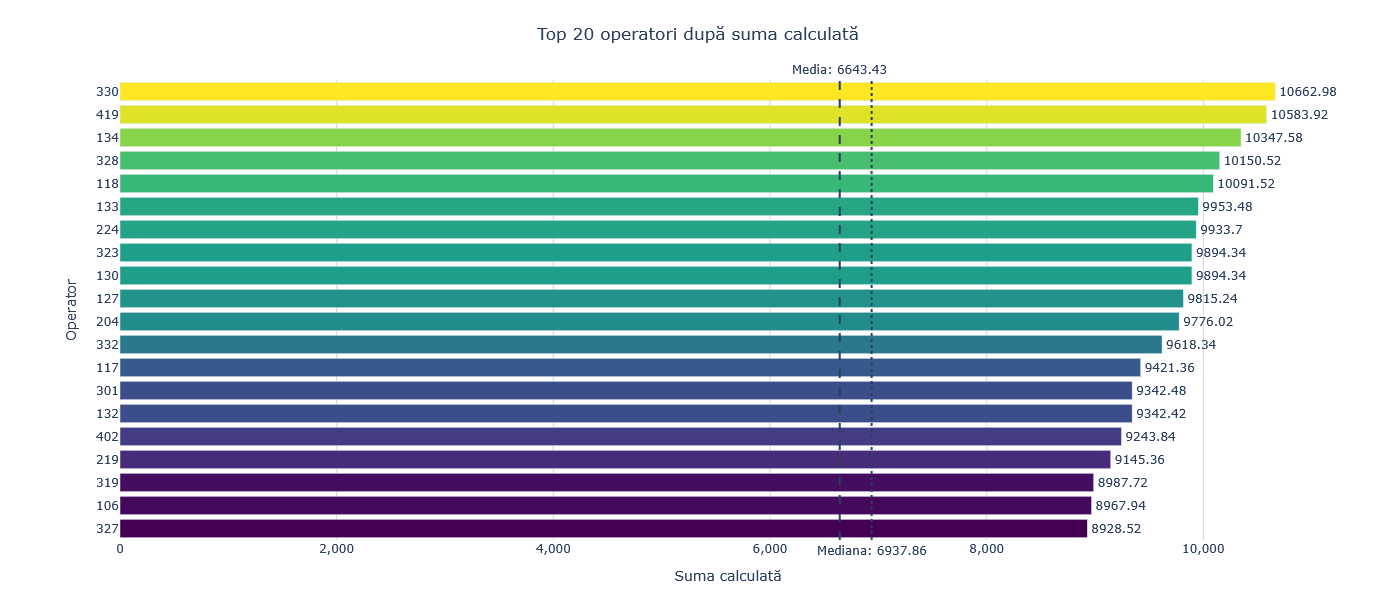

In [ ]:
import plotly.express as px

# Top 10 operatori după suma calculată
df_sorted = df.sort_values("suma_control", ascending=False).head(20).copy()

# Alegem coloana pentru operator
if "ENUM" in df_sorted.columns:
    operator_col = "ENUM"
elif "ENUM" in df_sorted.columns:
    operator_col = "ENUM"
else:
    df_sorted["operator"] = df_sorted.index.astype(str)
    operator_col = "operator"
# Sortare inversă pentru bar chart orizontal frumos
df_sorted = df_sorted.sort_values("suma_control", ascending=True)
# Media generală
media_suma = df["suma_control"].mean()
mediana_suma = df["suma_control"].median()
fig = px.bar(
    df_sorted,
    x="suma_control",
    y=operator_col,
    orientation="h",
    title="Top 20 operatori după suma calculată",
    text=df_sorted["suma_control"].round(2),
    color="suma_control",
    color_continuous_scale="Viridis",
    labels={
        "suma_control": "Suma calculată",
        operator_col: "Operator",
        "color": "Suma"
    },
    hover_data={
        operator_col: True,
        "suma_control": ":.2f",
        "sal_afm_realizat_recalc": True,
        "sal_cbgc_realizat_recalc": True,
        "NRf_AFM_recalc": True,
        "NRf_CBGC_recalc": True,
        "EBSf_AFM_recalc": True,
        "EBSf_CBGC_recalc": True
    }
)
# Linie verticală pentru media generală
fig.add_vline(
    x=media_suma,
    line_dash="dash",
    annotation_text=f"Media: {media_suma:.2f}",
    annotation_position="top"
)
# Linie verticală pentru mediana generală
fig.add_vline(
    x=mediana_suma,
    line_dash="dot",
    annotation_text=f"Mediana: {mediana_suma:.2f}",
    annotation_position="bottom"
)
fig.update_traces(
    textposition="outside",
    hovertemplate=(
        "<b>Operator:</b> %{y}<br>"
        "<b>Suma calculată:</b> %{x:.2f}<br>"
        "<extra></extra>"
    )
)
fig.update_layout(
    height=600,
    title={
        "text": "Top 20 operatori după suma calculată",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Suma calculată",
    yaxis_title="Operator",
    plot_bgcolor="white",
    paper_bgcolor="white",
    coloraxis_showscale=False,
    margin=dict(l=120, r=60, t=80, b=60)
)
fig.update_xaxes(
    showgrid=True,
    gridcolor="lightgray",
    tickformat=",.0f"
)
fig.update_yaxes(
    showgrid=False
)
fig.show()

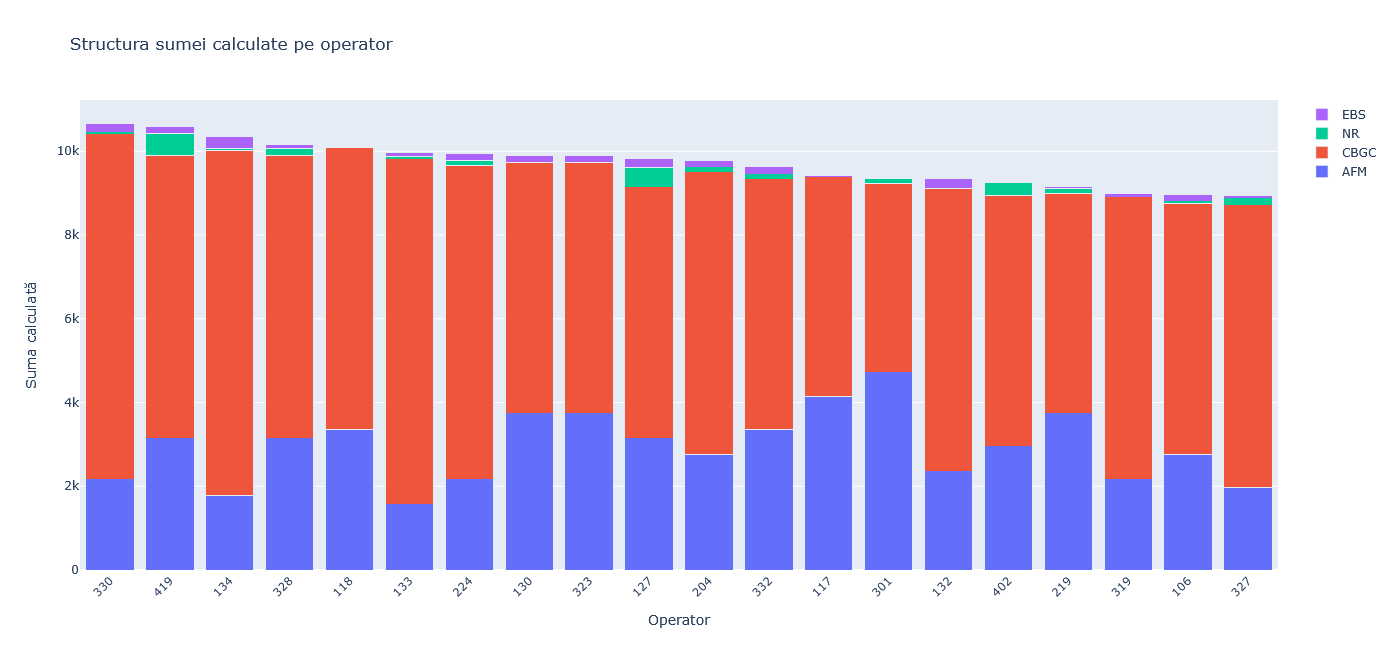

In [ ]:
#Grafic stacked: din ce este format salariul
#Aici vezi dacă salariul vine mai mult din AFM, CBGC, NR sau EBS.
df["suma_AFM"] = df["sal_afm_realizat_recalc"] * cost_chest_conventional
df["suma_CBGC"] = df["sal_cbgc_realizat_recalc"] * cost_chest_conventional * complexitate
df["suma_NR"] = (df["NRf_AFM_recalc"] + df["NRf_CBGC_recalc"]) * cost_nr
df["suma_EBS"] = (df["EBSf_AFM_recalc"] + df["EBSf_CBGC_recalc"]) * cost_conventional_EBS
# top10 = df.sort_values("suma_control", ascending=False).head(10)

# x = top10["ENUM"] if "ENUM" in df.columns else top10.index.astype(str)

# plt.figure(figsize=(13, 6))
# plt.bar(x, top10["suma_AFM"], label="AFM")
# plt.bar(x, top10["suma_CBGC"], bottom=top10["suma_AFM"], label="CBGC")
# plt.bar(x, top10["suma_NR"], bottom=top10["suma_AFM"] + top10["suma_CBGC"], label="NR")
# plt.bar(x, top10["suma_EBS"], bottom=top10["suma_AFM"] + top10["suma_CBGC"] + top10["suma_NR"], label="EBS")

# plt.xticks(rotation=90)
# plt.title("Structura sumei calculate pe operator")
# plt.xlabel("Operator")
# plt.ylabel("Suma")
# plt.legend()
# plt.tight_layout()
# plt.show()
import plotly.graph_objects as go

top20 = df.sort_values("suma_control", ascending=False).head(20).copy()

if "ENUM" in top20.columns:
    x_values = top20["ENUM"]
elif "ENUM" in top20.columns:
    x_values = top20["ENUM"].astype(str)
else:
    x_values = top20.index.astype(str)
custom_data = top20[[
    "sal_afm_realizat_recalc",
    "sal_cbgc_realizat_recalc",
    "NRf_AFM_recalc",
    "NRf_CBGC_recalc",
    "EBSf_AFM_recalc",
    "EBSf_CBGC_recalc",
    "suma_control"
]].values
hover_template = (
    "<b>%{x}</b><br>"
    "AFM chestionare: %{customdata[0]}<br>"
    "CBGC chestionare: %{customdata[1]}<br>"
    "NR AFM: %{customdata[2]}<br>"
    "NR CBGC: %{customdata[3]}<br>"
    "EBS AFM: %{customdata[4]}<br>"
    "EBS CBGC: %{customdata[5]}<br>"
    "Suma totală: %{customdata[6]:.2f}<br>"
    "<extra></extra>"
)
fig = go.Figure()
fig.add_trace(go.Bar(
    x=x_values,
    y=top20["suma_AFM"],
    name="AFM",
    customdata=custom_data,
    hovertemplate=hover_template
))
fig.add_trace(go.Bar(
    x=x_values,
    y=top20["suma_CBGC"],
    name="CBGC",
    customdata=custom_data,
    hovertemplate=hover_template
))
fig.add_trace(go.Bar(
    x=x_values,
    y=top20["suma_NR"],
    name="NR",
    customdata=custom_data,
    hovertemplate=hover_template
))
fig.add_trace(go.Bar(
    x=x_values,
    y=top20["suma_EBS"],
    name="EBS",
    customdata=custom_data,
    hovertemplate=hover_template
))
fig.update_layout(
    barmode="stack",
    title="Structura sumei calculate pe operator",
    xaxis_title="Operator",
    yaxis_title="Suma calculată",
    xaxis_tickangle=-45,
    height=650
)
fig.show()

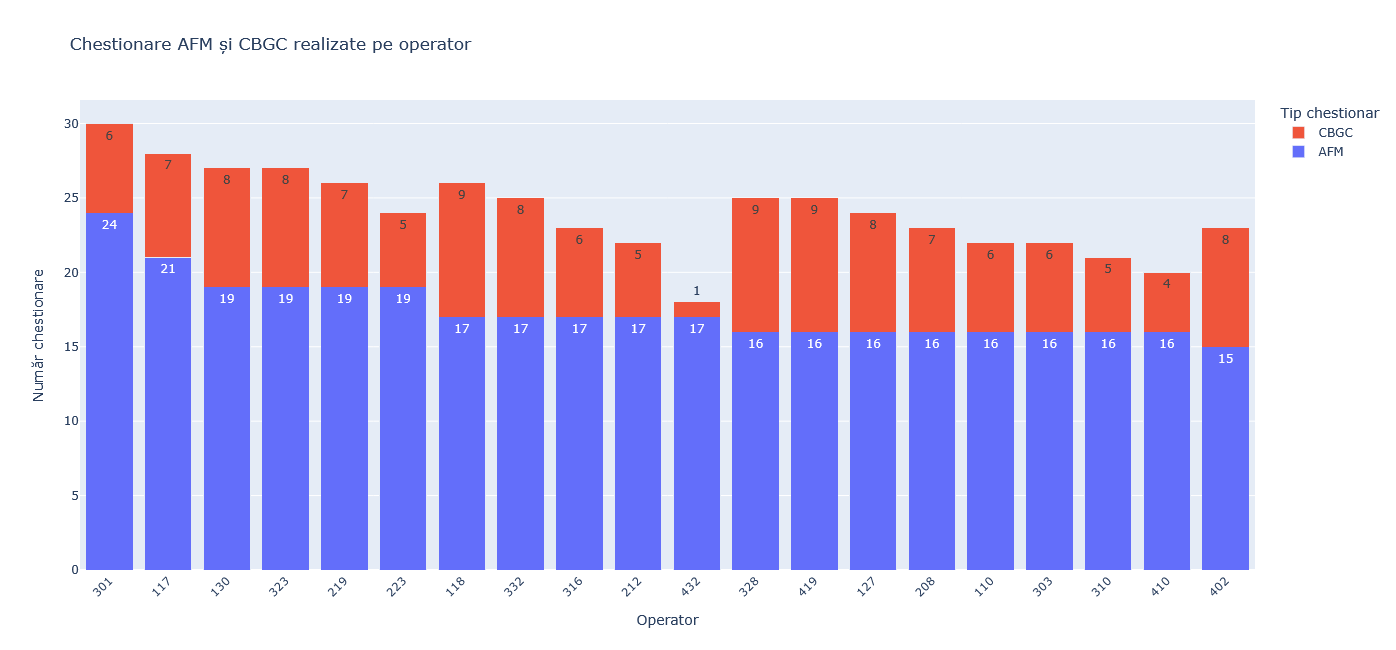

In [ ]:
#Grafic comparație AFM vs CBGC
#Pentru a vedea dacă operatorii au lucrat mai mult pe AFM sau CBGC:
# top20 = df.sort_values(
#     ["sal_afm_realizat_recalc", "sal_cbgc_realizat_recalc"],
#     ascending=False
# ).head(20)

# x = top20["ENUM"] if "ENUM" in df.columns else top20.index.astype(str)

# plt.figure(figsize=(13, 6))
# plt.bar(x, top20["sal_afm_realizat_recalc"], label="AFM")
# plt.bar(x, top20["sal_cbgc_realizat_recalc"],
#         bottom=top20["sal_afm_realizat_recalc"],
#         label="CBGC")

# plt.xticks(rotation=90)
# plt.title("Chestionare AFM și CBGC realizate pe operator")
# plt.xlabel("Operator")
# plt.ylabel("Număr chestionare")
# plt.legend()
# plt.tight_layout()
# plt.show()
# Top 20 operatori după AFM și CBGC
top20 = df.sort_values(
    ["sal_afm_realizat_recalc", "sal_cbgc_realizat_recalc"],
    ascending=False
).head(20).copy()

# Alegem ce afișăm pe axa X
if "ENUM" in top20.columns:
    x_values = top20["ENUM"]
elif "ENUM" in top20.columns:
    x_values = top20["ENUM"].astype(str)
else:
    x_values = top20.index.astype(str)
fig = go.Figure()

fig.add_trace(go.Bar(
    x=x_values,
    y=top20["sal_afm_realizat_recalc"],
    name="AFM",
    text=top20["sal_afm_realizat_recalc"],
    textposition="auto",
    hovertemplate=(
        "<b>Operator:</b> %{x}<br>"
        "<b>AFM:</b> %{y}<br>"
        "<extra></extra>"
    )
))
fig.add_trace(go.Bar(
    x=x_values,
    y=top20["sal_cbgc_realizat_recalc"],
    name="CBGC",
    text=top20["sal_cbgc_realizat_recalc"],
    textposition="auto",
    hovertemplate=(
        "<b>Operator:</b> %{x}<br>"
        "<b>CBGC:</b> %{y}<br>"
        "<extra></extra>"
    )
))
fig.update_layout(
    barmode="stack",
    title="Chestionare AFM și CBGC realizate pe operator",
    xaxis_title="Operator",
    yaxis_title="Număr chestionare",
    xaxis_tickangle=-45,
    height=650,
    legend_title="Tip chestionar"
)
fig.show()

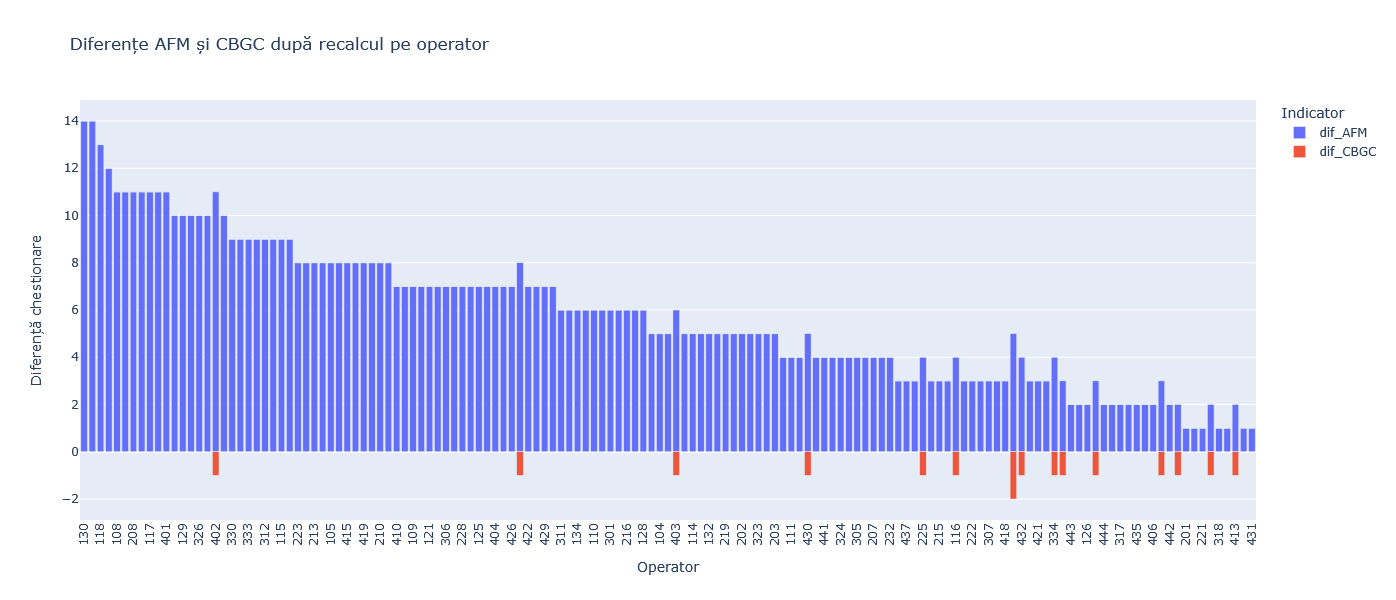

In [ ]:
#Indicator de diferențe / recalculări
#Pentru control, ar fi bine să vezi unde recalculul a schimbat mult valorile inițiale.
dif = df[df["dif_total_chestionare"] != 0].copy()
dif = dif.sort_values("dif_total_chestionare", ascending=False)

dif["operator"] = dif["ENUM"].astype(str) if "ENUM" in dif.columns else dif.index.astype(str)

fig = px.bar(
    dif,
    x="operator",
    y=["dif_AFM", "dif_CBGC"],
    title="Diferențe AFM și CBGC după recalcul pe operator",
    labels={
        "operator": "Operator",
        "value": "Diferență chestionare",
        "variable": "Indicator"
    },
    barmode="relative"
)

fig.update_layout(
    xaxis_tickangle=-90,
    height=600
)

fig.show()

In [ ]:
#Pregatirea sheetului pentru contabilitate
cols = ["ENUM_NAME","PA1_AFM_recalc","PA1_CBGC_recalc","NR_AFM_recalc","EBS_AFM_recalc","NR_CBGC_recalc","EBS_CBGC_recalc",f"sal_{luna_txt}","diff_sal_recalc_pers"]
df_contab = df[cols].copy()
df_contab["extra_spor"] = extra_spor
df_contab[f"sal_calc_spor_{luna_txt}"] = df_contab[f"sal_{luna_txt}"] + df_contab["diff_sal_recalc_pers"] + df_contab["extra_spor"]
print("Suma totala PA1_AFM_recalc: ", df_contab["PA1_AFM_recalc"].sum())
print("Suma totala NR_AFM_recalc: ", df_contab["NR_AFM_recalc"].sum())
print("Suma totala EBS_AFM_recalc: ", df_contab["EBS_AFM_recalc"].sum())
print("Suma totala PA1_CBGC_recalc: ", df_contab["PA1_CBGC_recalc"].sum())
print("Suma totala NR_CBGC_recalc: ", df_contab["NR_CBGC_recalc"].sum())
print("Suma totala EBS_CBGC_recalc: ", df_contab["EBS_CBGC_recalc"].sum())
print("Suma totala: ", df_contab[f"sal_{luna_txt}"].sum())
print("Suma totala spor: ", df_contab["diff_sal_recalc_pers"].sum())
print("Suma totala extra spor: ", df_contab["extra_spor"].sum())
print("Suma totala calculata: ", df_contab[f"sal_calc_spor_{luna_txt}"].sum())
print("Salariu mediu pe chestionar acceptat: ", df_contab[f"sal_calc_spor_{luna_txt}"].sum()/(df_contab["PA1_AFM_recalc"].sum() + df_contab["PA1_CBGC_recalc"].sum()))
#df_contab
#df_contabGroup = df_contab.groupby(["ENUM_NAME"]).sum()
df_contabGroup = df_contab.groupby(["ENUM"]).sum() #TODO sterge dupa instruire
#df_contabGroup.reset_index()[["ENUM_NAME", f"sal_calc_spor_{luna_txt}"]].to_csv("sal_Martie.csv", index=False)
df_contabGroup.index = df_contabGroup.index.map(
    lambda x: x.encode("cp1252", errors="ignore").decode("utf-8", errors="ignore")
    if isinstance(x, str) else x
)
#df_contabGroup.describe()
df_contabGroup["categorie"] = pd.cut(
    (df_contabGroup["PA1_AFM_recalc"] + df_contabGroup["PA1_CBGC_recalc"]),#numarul total de accepturi la AFM+CBGC
    bins=[0, 10, 20, 30,  float("inf")],#aici trebuie sa fie introdus intervalul dorit, cum categorizam operatorii
    labels=["Slab", "Mediu", "Bun", "Top"]#label a intervalului de mai sus
)
df_contabGroup.drop(columns=["ENUM_NAME"], errors="ignore")
#df_contabGroup["categorie"].value_counts() # afisarea numarului de operatori dupa categorie
#df_contabGroup["categorie"].value_counts(normalize=True) * 100 # afisarea in procente a operatorilor dupa categorie
#df_contabGroup.sort_values("sal_Martie", ascending=False).head(10)

In [ ]:
df_contabGroup.drop(columns=["ENUM_NAME"], errors="ignore").to_excel(f"DataOutput/sal_{luna_txt}_contab.xlsx", index=True)

![image.png](attachment:c216a0a0-8325-480d-9887-1f7e52e50a4e.png)